In [1]:
import config.config as cfg
import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv
load_dotenv(cfg.PROJ_ROOT)

y_name = 'dailycapitalization'
pd.set_option("display.max_columns", None)

2026-03-25 11:29:24.683 | INFO     | config.config:<module>:11 - PROJ_ROOT path is: /Users/alexander/PycharmProjects/vmk_thesis


## ПОДГОТОВКА ДАННЫХ

Reading

In [229]:
dtype_dict = {
    'secid': str,
    'boardid': str,
    'primary_boardid': str,
    'shortname': str,
    'inn': str,
    # 'tradedate': str,  # parse_dates отдельно
    'year': float,
    'dailycapitalization': float,
    'close': float,
    'volume': int,
    'sector': 'category',
    'type': str,
    'issuesize': float,
    'capex_revenue_rsbu': float,
    'capex_revenue_msfo': float,
    'capital_rsbu': float,
    'capital_msfo': float,
    'current_ratio_rsbu': float,
    'current_ratio_msfo': float,
    'debt_equity_rsbu': float,
    'debt_equity_msfo': float,
    'debt_ratio_rsbu': float,
    'debt_ratio_msfo': float,
    'debtebitda_rsbu': float,
    'debtebitda_msfo': float,
    'dpr_rsbu': float,
    'dpr_msfo': float,
    'ebitda_margin_rsbu': float,
    'ebitda_margin_msfo': float,
    'ev_ebit_rsbu': float,
    'ev_ebit_msfo': float,
    'evebitda_rsbu': float,
    'evebitda_msfo': float,
    'evs_rsbu': float,
    'evs_msfo': float,
    'gross_margin_rsbu': float,
    'gross_margin_msfo': float,
    'interest_coverage_rsbu': float,
    'interest_coverage_msfo': float,
    'net_margin_rsbu': float,
    'net_margin_msfo': float,
    'net_working_capital_rsbu': float,
    'net_working_capital_msfo': float,
    'netdebt_ebitda_rsbu': float,
    'netdebt_ebitda_msfo': float,
    'operation_margin_rsbu': float,
    'operation_margin_msfo': float,
    'pbv_rsbu': float,
    'pbv_msfo': float,
    'pcf_rsbu': float,
    'pcf_msfo': float,
    'pe_rsbu': float,
    'pe_msfo': float,
    'pfcf_rsbu': float,
    'pfcf_msfo': float,
    'pffo_rsbu': float,
    'pffo_msfo': float,
    'ps_rsbu': float,
    'ps_msfo': float,
    'roa_rsbu': float,
    'roa_msfo': float,
    'roce_rsbu': float,
    'roce_msfo': float,
    'roe_rsbu': float,
    'roe_msfo': float,
    'roic_rsbu': float,
    'roic_msfo': float,
    'ros_rsbu': float,
    'ros_msfo': float,
    'line_1100': float,
    'line_1110': float,
    'line_1120': float,
    'line_1130': float,
    'line_1140': float,
    'line_1150': float,
    'line_1160': float,
    'line_1170': float,
    'line_1180': float,
    'line_1190': float,
    'line_1200': float,
    'line_1210': float,
    'line_1220': float,
    'line_1230': float,
    'line_1240': float,
    'line_1250': float,
    'line_1260': float,
    'line_1300': float,
    'line_1310': float,
    'line_1320': float,
    'line_1340': float,
    'line_1350': float,
    'line_1360': float,
    'line_1370': float,
    'line_1400': float,
    'line_1410': float,
    'line_1420': float,
    'line_1430': float,
    'line_1450': float,
    'line_1500': float,
    'line_1510': float,
    'line_1520': float,
    'line_1530': float,
    'line_1540': float,
    'line_1550': float,
    'line_1600': float,
    'line_1700': float,
    'line_2100': float,
    'line_2110': float,
    'line_2120': float,
    'line_2200': float,
    'line_2210': float,
    'line_2220': float,
    'line_2300': float,
    'line_2310': float,
    'line_2320': float,
    'line_2330': float,
    'line_2340': float,
    'line_2350': float,
    'line_2400': float,
    'line_2410': float,
    'line_2411': float,
    'line_2412': float,
    'line_2421': float,
    'line_2430': float,
    'line_2450': float,
    'line_2460': float,
    'line_2500': float,
    'line_2510': float,
    'line_2520': float,
    'line_2530': float,
    'line_2900': float,
    'line_2910': float,
    'line_3100': float,
    'line_3200': float,
    'line_3210': float,
    'line_3211': float,
    'line_3212': float,
    'line_3213': float,
    'line_3214': float,
    'line_3215': float,
    'line_3216': float,
    'line_321x': float,
    'line_3220': float,
    'line_3221': float,
    'line_3222': float,
    'line_3223': float,
    'line_3224': float,
    'line_3225': float,
    'line_3226': float,
    'line_3227': float,
    'line_322x': float,
    'line_3230': float,
    'line_3240': float,
    'line_3300': float,
    'line_3310': float,
    'line_3311': float,
    'line_3312': float,
    'line_3313': float,
    'line_3314': float,
    'line_3315': float,
    'line_3316': float,
    'line_331x': float,
    'line_3320': float,
    'line_3321': float,
    'line_3322': float,
    'line_3323': float,
    'line_3324': float,
    'line_3325': float,
    'line_3326': float,
    'line_3327': float,
    'line_332x': float,
    'line_3330': float,
    'line_3340': float,
    'line_3400': float,
    'line_3401': float,
    'line_3402': float,
    'line_3410': float,
    'line_3411': float,
    'line_3412': float,
    'line_3420': float,
    'line_3421': float,
    'line_3422': float,
    'line_3500': float,
    'line_3501': float,
    'line_3502': float,
    'line_3600': float,
    'line_4100': float,
    'line_4110': float,
    'line_4111': float,
    'line_4112': float,
    'line_4113': float,
    'line_4119': float,
    'line_411x': float,
    'line_4120': float,
    'line_4121': float,
    'line_4122': float,
    'line_4123': float,
    'line_4124': float,
    'line_4129': float,
    'line_412x': float,
    'line_4200': float,
    'line_4210': float,
    'line_4211': float,
    'line_4212': float,
    'line_4213': float,
    'line_4214': float,
    'line_4219': float,
    'line_421x': float,
    'line_4220': float,
    'line_4221': float,
    'line_4222': float,
    'line_4223': float,
    'line_4224': float,
    'line_4229': float,
    'line_422x': float,
    'line_4300': float,
    'line_4310': float,
    'line_4311': float,
    'line_4312': float,
    'line_4313': float,
    'line_4314': float,
    'line_4319': float,
    'line_431x': float,
    'line_4320': float,
    'line_4321': float,
    'line_4322': float,
    'line_4323': float,
    'line_4329': float,
    'line_432x': float,
    'line_4400': float,
    'line_4450': float,
    'line_4490': float,
    'line_4500': float,
    'line_6100': float,
    'line_6200': float,
    'line_6210': float,
    'line_6215': float,
    'line_6220': float,
    'line_6230': float,
    'line_6240': float,
    'line_6250': float,
    'line_6300': float,
    'line_6310': float,
    'line_6311': float,
    'line_6312': float,
    'line_6313': float,
    'line_6320': float,
    'line_6321': float,
    'line_6322': float,
    'line_6323': float,
    'line_6324': float,
    'line_6325': float,
    'line_6326': float,
    'line_6330': float,
    'line_6350': float,
    'line_6400': float,
    'key_rate': float,
    'inflation': float,
    'str_li_def_new': float,
    'str_li_def': float,
    'claims': float,
    'action_based_repo_fx': float,
    'action_based_secure_loans': float,
    'standing_facilities_repo_fx': float,
    'standing_facilities_secure_loans': float,
    'liabilities': float,
    'deposit_auction_based': float,
    'deposit_standing_facilities': float,
    'cbr_bonds': float,
    'net_cbr_claims': float,
    'corr_acc': float,
    'avgrr': float,
    'gold_price': float,
    'silver_price': float,
    'platinum_price': float,
    'palladium_price': float,
    'usd_price': float,
    'eur_price': float,
    'ruonia_rate': float,
    'ruonia_volume': float
}

In [230]:
df = pd.read_csv(
    cfg.PROJ_ROOT / 'data' / 'raw' / 'dataset.csv',
    parse_dates=['tradedate'],
    sep='\t',
    dtype=dtype_dict,
)
df['tradedate'] = pd.to_datetime(df['tradedate'])
df['tradeyear'] = df['tradedate'].dt.year

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/3825923207.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['tradeyear'] = df['tradedate'].dt.year


In [231]:
df['boardid'].unique()

<StringArray>
['TQBR', 'TQPI', 'SMAL', 'EQDP', 'TQDE', 'EQNE', 'EQBS', 'EQLI', 'EQNL',
 'EQBR', 'EQLV', 'TQNL', 'EQDE', 'TQNE', 'TQBS', 'SPEQ', 'EQCC', 'TQLV',
 'TQDP']
Length: 19, dtype: str

	•	TQBR — акции, основной стакан (T+2)
	•	TQBS — акции, T+ режим (вариация расчётов, реже используется)
	•	TQPI — режим для квалифицированных инвесторов
	•	TQDE — депозитарные расписки
	•	TQDP — DR / спецрежим
	•	TQNE — адресные сделки в T+
	•	TQLV — низколиквидные бумаги
	•	TQNL — неликвид / ограниченный режим
	•	EQBR — акции (аналог TQBR, но менее ликвидный)
	•	EQNE — адресные сделки
	•	EQBS — режим расчётов
	•	EQLI — листинг / малоликвидные
	•	EQNL — неликвид
	•	EQLV — low volume
	•	EQDE — депозитарные расписки
	•	EQDP — DR / спецрежим
	•	EQCC — клиринговый / спецрежим
	•	SMAL — неполные лоты (odd lots)
	•	SPEQ — negotiated / специальные сделки

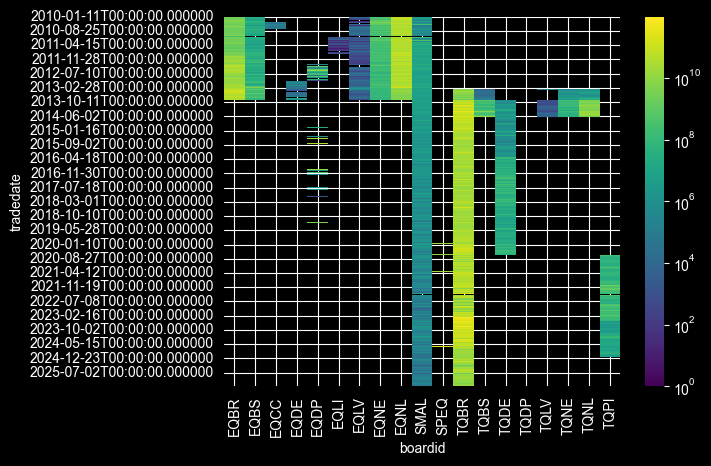

In [232]:
pivot = df.pivot_table(
    index='tradedate',
    columns='boardid',
    values='volume',
    aggfunc='sum'
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pivot, cmap='viridis', norm='log')
plt.show()

In [233]:
## TODO
# 1. Найти все корректные инн DONE
# 2. Обработать допэмиссии
# 3. собрать данные отчетности из цбрф по кредитным организациям

### TODO обработать допэмиссию. Пока что выброшу ее

In [234]:
mask = df['secid'].str.contains(r'-0', na=False)
base = df.loc[mask, 'secid'].str.extract(r'^(.+?)-0')[0]
df = df[~df['secid'].isin(pd.concat([df.loc[mask, 'secid'], base]))]
df.shape

(1676433, 281)

In [235]:
df = df[df['boardid'].isin(['TQBR', 'EQBR', 'TQBS', 'EQBS'])]

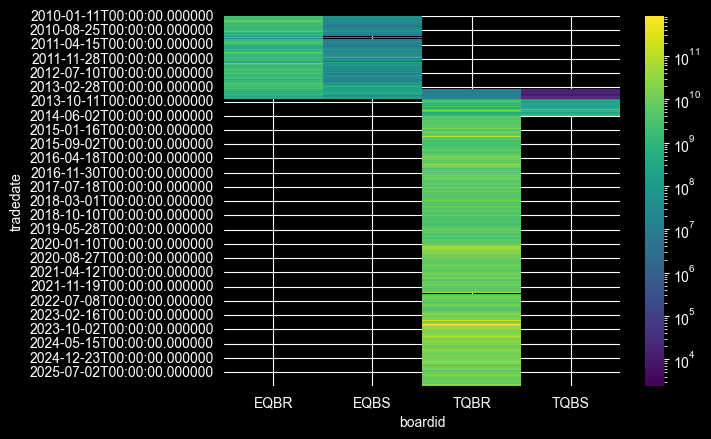

In [236]:
pivot = df.pivot_table(
    index='tradedate',
    columns='boardid',
    values='volume',
    aggfunc='sum'
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pivot, cmap='viridis', norm='log')
plt.show()

In [237]:
df = df.loc[df.groupby(['secid', 'tradedate'])['volume'].idxmax()]

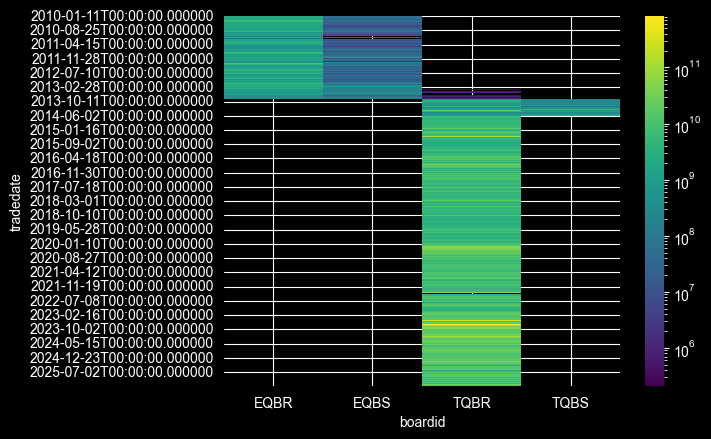

In [238]:
pivot = df.pivot_table(
    index='tradedate',
    columns='boardid',
    values='volume',
    aggfunc='sum'
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pivot, cmap='viridis', norm='log')
plt.show()

In [239]:
df.shape

(761862, 281)

TEMPORARY

In [240]:
df['type'] = df['type'].fillna('common_share').astype('category')
df = df[df['type'].isin(['common_share', 'preferred_share'])]
df['sector'] = df['sector'].astype('category')
df['sector'].replace('', np.nan, inplace=True)
df[y_name].replace(0, np.nan, inplace=True)
df['close'].replace(0, np.nan, inplace=True)
df['volume'].replace(0, np.nan, inplace=True)
df['outstanding_shares'] = df[y_name] / df['close']
df.sort_values(['secid', 'tradedate', 'boardid'], inplace=True)

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/1758574299.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['sector'].replace('', np.nan, inplace=True)
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/1758574299.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Serie

Imputation

In [241]:
df['outstanding_shares'] = df.groupby('secid')['outstanding_shares'].ffill()
nullcap = df[y_name].isna()
df.loc[nullcap, y_name] = df.loc[nullcap, 'close'] * df.loc[nullcap, 'outstanding_shares']

In [242]:
df['outstanding_shares'] = df.groupby('secid')['outstanding_shares'].bfill()
nullcap = df[y_name].isna()
df.loc[nullcap, y_name] = df.loc[nullcap, 'close'] * df.loc[nullcap, 'outstanding_shares']

In [243]:
df['close'] = df.groupby('secid')['close'].ffill()
nullcap = df[y_name].isna()
df.loc[nullcap, y_name] = df.loc[nullcap, 'close'] * df.loc[nullcap, 'outstanding_shares']

In [244]:
df['close'] = df.groupby('secid')['close'].bfill()
nullcap = df[y_name].isna()
df.loc[nullcap, y_name] = df.loc[nullcap, 'close'] * df.loc[nullcap, 'outstanding_shares']

In [245]:
size = df['issuesize'] > 0
df.loc[size, 'outstanding_shares'] = df.loc[size, 'outstanding_shares'].combine_first(df.loc[size, 'issuesize'])

In [246]:
nullcap = df[y_name].isna()
df.loc[nullcap, y_name] = df.loc[nullcap, 'close'] * df.loc[nullcap, 'outstanding_shares']

In [247]:
df[y_name] = df.groupby('secid')[y_name].ffill()
df[y_name] = df.groupby('secid')[y_name].bfill()

In [248]:
df['volume'] = df.groupby('secid')['volume'].ffill()
df['volume'] = df.groupby('secid')['volume'].bfill()

In [249]:
nullcap = df[y_name].isna() & ~df['close'].isna()
df.loc[nullcap, 'outstanding_shares'] = df['outstanding_shares'].mean()
df.loc[nullcap, y_name] = df.loc[nullcap, 'close'] * df.loc[nullcap, 'outstanding_shares']

In [250]:
df = df[df[y_name]>1e-6]

In [251]:
df[['key_rate', 'inflation', 'str_li_def_new', 'str_li_def', 'claims', 'action_based_repo_fx', 'action_based_secure_loans', 'standing_facilities_repo_fx', 'standing_facilities_secure_loans', 'liabilities', 'deposit_auction_based', 'deposit_standing_facilities', 'cbr_bonds', 'net_cbr_claims', 'corr_acc', 'avgrr', 'gold_price', 'silver_price', 'platinum_price', 'palladium_price', 'usd_price', 'eur_price', 'ruonia_rate', 'ruonia_volume']] = \
df.groupby('secid')[['key_rate', 'inflation', 'str_li_def_new', 'str_li_def', 'claims', 'action_based_repo_fx', 'action_based_secure_loans', 'standing_facilities_repo_fx', 'standing_facilities_secure_loans', 'liabilities', 'deposit_auction_based', 'deposit_standing_facilities', 'cbr_bonds', 'net_cbr_claims', 'corr_acc', 'avgrr', 'gold_price', 'silver_price', 'platinum_price', 'palladium_price', 'usd_price', 'eur_price', 'ruonia_rate', 'ruonia_volume']].ffill()
df[['key_rate', 'inflation', 'str_li_def_new', 'str_li_def', 'claims', 'action_based_repo_fx', 'action_based_secure_loans', 'standing_facilities_repo_fx', 'standing_facilities_secure_loans', 'liabilities', 'deposit_auction_based', 'deposit_standing_facilities', 'cbr_bonds', 'net_cbr_claims', 'corr_acc', 'avgrr', 'gold_price', 'silver_price', 'platinum_price', 'palladium_price', 'usd_price', 'eur_price', 'ruonia_rate', 'ruonia_volume']] = \
df.groupby('secid')[['key_rate', 'inflation', 'str_li_def_new', 'str_li_def', 'claims', 'action_based_repo_fx', 'action_based_secure_loans', 'standing_facilities_repo_fx', 'standing_facilities_secure_loans', 'liabilities', 'deposit_auction_based', 'deposit_standing_facilities', 'cbr_bonds', 'net_cbr_claims', 'corr_acc', 'avgrr', 'gold_price', 'silver_price', 'platinum_price', 'palladium_price', 'usd_price', 'eur_price', 'ruonia_rate', 'ruonia_volume']].bfill()

Filter years

In [252]:
df = df[(~df['year'].isna()) & (~df['inn'].isna())]
df = df[~df[y_name].isna()]
df['year'] = df['year'].astype(int)
df['tradedate'] = pd.to_datetime(df['tradedate'])
df.shape

(607497, 282)

In [253]:
df['secid'].nunique()

357

In [254]:
df['inn'] = df['inn'].str.zfill(10)

In [255]:
df = df.sort_values(['secid', 'tradedate'])

In [256]:
def canonical_secid(group):
    # минимальная длина
    min_len = group['secid'].str.len().min()
    candidates = group[group['secid'].str.len() == min_len]
    # если несколько кандидатов — берём первый по tradedate
    return candidates['secid'].iloc[0]

In [257]:
df_common = df[df['type'] == 'common_share']
df_preferred = df[df['type'] == 'preferred_share']

In [258]:
inn_to_secid = df_common.groupby('inn').apply(canonical_secid).to_dict()
df_common['secid'] = df_common['inn'].map(inn_to_secid)
df_common = df_common.loc[df_common.groupby(['secid', 'tradedate'])['volume'].idxmax()].reset_index(drop=True)
inn_to_secid = df_preferred.groupby('inn').apply(canonical_secid).to_dict()
df_preferred['secid'] = df_preferred['inn'].map(inn_to_secid)
df_preferred = df_preferred.loc[df_preferred.groupby(['secid', 'tradedate'])['volume'].idxmax()].reset_index(drop=True)

In [274]:
inn_to_secid

{'0274018377': 'BISVP',
 '1215099739': 'MISBP',
 '1402047184': 'SELGP',
 '1435028701': 'YKENP',
 '1644003838': 'TATNP',
 '1651000010': 'NKNCP',
 '1826000655': 'IGSTP',
 '2124009521': 'HIMCP',
 '2334021010': 'DNKOP',
 '2346000311': 'SXPNP',
 '2373011150': 'KUSTP',
 '2466132221': 'KRSBP',
 '2626033550': 'STSBP',
 '2801133630': 'VRAOP',
 '3411004254': 'RODNP',
 '3445071523': 'VGSBP',
 '3663050467': 'VRSBP',
 '3802000096': 'LNZLP',
 '4100000668': 'KCHEP',
 '4345479720': 'KISBP',
 '4704012874': 'VSYDP',
 '4716016979': 'MRKHP',
 '4717001132': 'TRUDP',
 '4909047148': 'MAGEP',
 '5190141373': 'MUGSP',
 '5200000046': 'GAZAP',
 '5248004137': 'ZMZNP',
 '5260148520': 'NNSBP',
 '5260901817': 'VTELP',
 '5411100018': 'NVNGP',
 '5612042824': 'SVSBP',
 '5902183094': 'URSIP',
 '5904123809': 'PMSBP',
 '6154023009': 'KRKOP',
 '6168002922': 'RTSBP',
 '6315222985': 'SAGOP',
 '6320002223': 'AVAZP',
 '6320005915': 'KAZTP',
 '6451114900': 'KRKNP',
 '6663059899': 'OMZZP',
 '6704000505': 'DGBZP',
 '6829010210': '

Set index secid and tradedate

In [259]:
df = pd.concat([df_common, df_preferred], ignore_index=True)
df = df.reset_index().sort_values(['secid', 'tradedate']).set_index(['secid', 'tradedate'])
df.drop(columns=['index'], inplace=True)

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/910716688.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.reset_index().sort_values(['secid', 'tradedate']).set_index(['secid', 'tradedate'])


In [260]:
df.shape

(595037, 280)

In [261]:
df['sector'].replace('na', np.nan, inplace=True)
df['issuesize'].replace(0, np.nan, inplace=True)
df['volume'].replace(0, np.nan, inplace=True)
df[['sector', 'issuesize', 'volume']] = df.groupby(level=0)[['sector', 'issuesize', 'volume']].ffill()
df[['sector', 'issuesize', 'volume']] = df.groupby(level=0)[['sector', 'issuesize', 'volume']].bfill()

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/3349940100.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['sector'].replace('na', np.nan, inplace=True)
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/3349940100.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

In [262]:
df.to_csv(cfg.PROJ_ROOT / 'data' / 'temporary' / 'dataset_cleaned.csv')

In [265]:
df[y_name].describe()

count    5.950370e+05
mean     1.604115e+11
std      5.944997e+11
min      9.153103e+06
25%      9.601825e+08
50%      6.115931e+09
75%      4.403460e+10
max      9.108147e+12
Name: dailycapitalization, dtype: float64

In [266]:
df[df[y_name]<1e-6]

,,boardid,primary_boardid,shortname,inn,year,dailycapitalization,close,volume,sector,type,issuesize,capex_revenue_rsbu,capex_revenue_msfo,capital_rsbu,capital_msfo,current_ratio_rsbu,current_ratio_msfo,debt_equity_rsbu,debt_equity_msfo,debt_ratio_rsbu,debt_ratio_msfo,debtebitda_rsbu,debtebitda_msfo,dpr_rsbu,dpr_msfo,ebitda_margin_rsbu,ebitda_margin_msfo,ev_ebit_rsbu,ev_ebit_msfo,evebitda_rsbu,evebitda_msfo,evs_rsbu,evs_msfo,gross_margin_rsbu,gross_margin_msfo,interest_coverage_rsbu,interest_coverage_msfo,net_margin_rsbu,net_margin_msfo,net_working_capital_rsbu,net_working_capital_msfo,netdebt_ebitda_rsbu,netdebt_ebitda_msfo,operation_margin_rsbu,operation_margin_msfo,pbv_rsbu,pbv_msfo,pcf_rsbu,pcf_msfo,pe_rsbu,pe_msfo,pfcf_rsbu,pfcf_msfo,pffo_rsbu,pffo_msfo,ps_rsbu,ps_msfo,roa_rsbu,roa_msfo,roce_rsbu,roce_msfo,roe_rsbu,roe_msfo,roic_rsbu,roic_msfo,ros_rsbu,ros_msfo,line_1100,line_1110,line_1120,line_1130,line_1140,line_1150,line_1160,line_1170,line_1180,line_1190,line_1200,line_1210,line_1220,line_1230,line_1240,line_1250,line_1260,line_1300,line_1310,line_1320,line_1340,line_1350,line_1360,line_1370,line_1400,line_1410,line_1420,line_1430,line_1450,line_1500,line_1510,line_1520,line_1530,line_1540,line_1550,line_1600,line_1700,line_2100,line_2110,line_2120,line_2200,line_2210,line_2220,line_2300,line_2310,line_2320,line_2330,line_2340,line_2350,line_2400,line_2410,line_2411,line_2412,line_2421,line_2430,line_2450,line_2460,line_2500,line_2510,line_2520,line_2530,line_2900,line_2910,line_3100,line_3200,line_3210,line_3211,line_3212,line_3213,line_3214,line_3215,line_3216,line_321x,line_3220,line_3221,line_3222,line_3223,line_3224,line_3225,line_3226,line_3227,line_322x,line_3230,line_3240,line_3300,line_3310,line_3311,line_3312,line_3313,line_3314,line_3315,line_3316,line_331x,line_3320,line_3321,line_3322,line_3323,line_3324,line_3325,line_3326,line_3327,line_332x,line_3330,line_3340,line_3400,line_3401,line_3402,line_3410,line_3411,line_3412,line_3420,line_3421,line_3422,line_3500,line_3501,line_3502,line_3600,line_4100,line_4110,line_4111,line_4112,line_4113,line_4119,line_411x,line_4120,line_4121,line_4122,line_4123,line_4124,line_4129,line_412x,line_4200,line_4210,line_4211,line_4212,line_4213,line_4214,line_4219,line_421x,line_4220,line_4221,line_4222,line_4223,line_4224,line_4229,line_422x,line_4300,line_4310,line_4311,line_4312,line_4313,line_4314,line_4319,line_431x,line_4320,line_4321,line_4322,line_4323,line_4329,line_432x,line_4400,line_4450,line_4490,line_4500,line_6100,line_6200,line_6210,line_6215,line_6220,line_6230,line_6240,line_6250,line_6300,line_6310,line_6311,line_6312,line_6313,line_6320,line_6321,line_6322,line_6323,line_6324,line_6325,line_6326,line_6330,line_6350,line_6400,key_rate,inflation,str_li_def_new,str_li_def,claims,action_based_repo_fx,action_based_secure_loans,standing_facilities_repo_fx,standing_facilities_secure_loans,liabilities,deposit_auction_based,deposit_standing_facilities,cbr_bonds,net_cbr_claims,corr_acc,avgrr,gold_price,silver_price,platinum_price,palladium_price,usd_price,eur_price,ruonia_rate,ruonia_volume,tradeyear,outstanding_shares
secid,tradedate,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


<Axes: xlabel='secid,tradedate'>

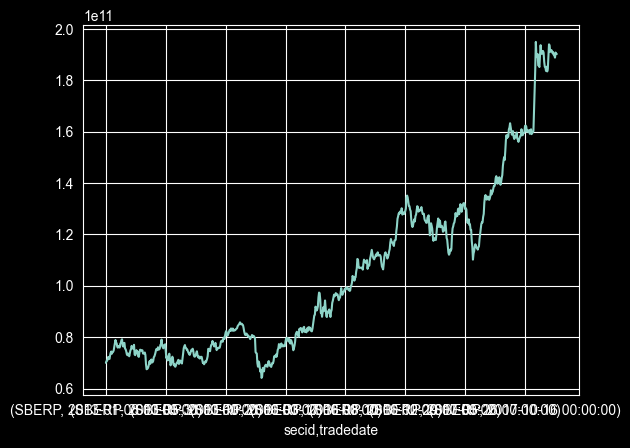

In [273]:
df[df.index.get_level_values(0)=='SBERP'][y_name].plot()

One-Hot Encoding sector and type

In [275]:
df = pd.get_dummies(df, columns=['sector', 'type', 'boardid'], drop_first=True)

Lags and windows

In [276]:
def create_lagged_features(df: pd.DataFrame, lags: list[int]) -> pd.DataFrame:
    """
    Create lagged features and returns for specified columns and lags.
    """
    for lag in lags:
        df[f'log_returns_{lag}'] = np.log(df[y_name]).diff(lag)
        df[f'pct_returns_{lag}'] = df[y_name].pct_change(periods=lag) * 100
    return df

In [277]:
def create_windowed_features(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    """
    Create rolling window features and returns for specified columns and window sizes.
    """
    for window in windows:
        df[f'cap_rolling_mean_{window}'] = df[y_name].shift(1).rolling(window).mean()
        df[f'log_returns_rolling_mean_{window}'] = np.log(df[y_name]/df[f'cap_rolling_mean_{window}'])
        df[f'pct_returns_rolling_mean_{window}'] = df[y_name]/df[f'cap_rolling_mean_{window}'] * 100
    return df

In [278]:
lags = [1, 5, 10, 20, 60, 120, 365]
windows = [5, 10, 20, 60, 120, 365]
df = create_lagged_features(df, lags=lags)
df = create_windowed_features(df, windows=windows)

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/1204692665.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'log_returns_{lag}'] = np.log(df[y_name]).diff(lag)
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/1204692665.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'pct_returns_{lag}'] = df[y_name].pct_change(periods=lag) * 100
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/1208750431.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the

In [279]:
df['pct_volume_1'] = df['volume'].pct_change(periods=1) * 100
df['log_volume_1'] = np.log(df['volume']).diff(1)

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/1021180108.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['pct_volume_1'] = df['volume'].pct_change(periods=1) * 100
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/1021180108.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['

Exponential Smoothing

In [280]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 2.8 MB/s eta 0:00:00 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 7.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [281]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def exponential_smoothing(
    s: pd.Series,
    trend: str = None,           # None, 'add', 'mul'
    seasonal: str = None,        # None, 'add', 'mul'
    seasonal_periods: int = None,
    alpha: float = None,         # smoothing_level
    beta: float = None,          # smoothing_slope
    gamma: float = None          # smoothing_seasonal
) -> pd.Series:
    """
    Exponential smoothing (Single, Double, Triple) for a pandas Series.
    Returns Series with the same index.
    """

    model = ExponentialSmoothing(
        s,
        trend=trend,
        seasonal=seasonal,
        seasonal_periods=seasonal_periods
    )

    fit = model.fit(
        smoothing_level=alpha,
        smoothing_slope=beta,
        smoothing_seasonal=gamma,
        optimized=(alpha is None and beta is None and gamma is None)
    )

    return pd.Series(fit.fittedvalues, index=s.index, name=s.name)

In [282]:
df['cap_ewm_0.1'] = exponential_smoothing(df[y_name], alpha=0.1)
df['cap_ewm_0.5'] = exponential_smoothing(df[y_name], alpha=0.5)
df['cap_des_0.1_0.1'] = exponential_smoothing(df[y_name], alpha=0.1, beta=0.1)
df['cap_des_0.1_0.1'] = exponential_smoothing(df[y_name], alpha=0.5, beta=0.1)

/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/38755016.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cap_ewm_0.1'] = exponential_smoothing(df[y_name], alpha=0.1)
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of 

Day of week

In [283]:
df['day_of_week'] = df.index.get_level_values(1).day_of_week

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/2063292998.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day_of_week'] = df.index.get_level_values(1).day_of_week


Smoothing annual reports data

In [284]:
import numpy as np
from scipy.interpolate import CubicSpline
from datetime import date

TARGET_DATES = pd.to_datetime(
    [date(y, 3, 15) for y in range(2011, 2025)]
)


def smooth_report_data(
    s: pd.Series,
    report_dates: pd.DatetimeIndex = TARGET_DATES
) -> pd.Series:

    if s.empty:
        return s

    idx = pd.DatetimeIndex(s.index)
    s = s.astype(float).fillna(0.0)

    anchors = {}

    for d in report_dates:
        mask = idx.year == d.year
        if not mask.any():
            continue

        year_idx = idx[mask]
        nearest = year_idx[np.abs(year_idx - d).argmin()]

        value = s.loc[nearest]

        anchors[nearest] = float(value)

    anchors = pd.Series(anchors).sort_index()

    if len(anchors) < 2:
        return s

    t_anchor = anchors.index.view("int64")
    t_all = idx.view("int64")

    if np.any(np.diff(t_anchor) <= 0):
        return s

    y_smooth = CubicSpline(
        t_anchor,
        anchors.values,
        bc_type="natural"
    )(t_all)

    return pd.Series(y_smooth, index=s.index, name=s.name)

In [285]:
mults = [
    'capex_revenue_rsbu', 'capex_revenue_msfo', 'capital_rsbu', 'capital_msfo', 'current_ratio_rsbu', 'current_ratio_msfo', 'debt_equity_rsbu', 'debt_equity_msfo', 'debt_ratio_rsbu', 'debt_ratio_msfo', 'debtebitda_rsbu', 'debtebitda_msfo', 'dpr_rsbu', 'dpr_msfo', 'ebitda_margin_rsbu', 'ebitda_margin_msfo', 'ev_ebit_rsbu', 'ev_ebit_msfo', 'evebitda_rsbu', 'evebitda_msfo', 'evs_rsbu', 'evs_msfo', 'gross_margin_rsbu', 'gross_margin_msfo', 'interest_coverage_rsbu', 'interest_coverage_msfo', 'net_margin_rsbu', 'net_margin_msfo', 'net_working_capital_rsbu', 'net_working_capital_msfo', 'netdebt_ebitda_rsbu', 'netdebt_ebitda_msfo', 'operation_margin_rsbu', 'operation_margin_msfo', 'pbv_rsbu', 'pbv_msfo', 'pcf_rsbu', 'pcf_msfo', 'pe_rsbu', 'pe_msfo', 'pfcf_rsbu', 'pfcf_msfo', 'pffo_rsbu', 'pffo_msfo', 'ps_rsbu', 'ps_msfo', 'roa_rsbu', 'roa_msfo', 'roce_rsbu', 'roce_msfo', 'roe_rsbu', 'roe_msfo', 'roic_rsbu', 'roic_msfo', 'ros_rsbu', 'ros_msfo',
]
funds = [
    'line_1100', 'line_1110', 'line_1120', 'line_1130', 'line_1140', 'line_1150', 'line_1160', 'line_1170', 'line_1180', 'line_1190', 'line_1200', 'line_1210', 'line_1220', 'line_1230', 'line_1240', 'line_1250', 'line_1260', 'line_1300', 'line_1310', 'line_1320', 'line_1340', 'line_1350', 'line_1360', 'line_1370', 'line_1400', 'line_1410', 'line_1420', 'line_1430', 'line_1450', 'line_1500', 'line_1510', 'line_1520', 'line_1530', 'line_1540', 'line_1550', 'line_1600', 'line_1700', 'line_2100', 'line_2110', 'line_2120', 'line_2200', 'line_2210', 'line_2220', 'line_2300', 'line_2310', 'line_2320', 'line_2330', 'line_2340', 'line_2350', 'line_2400', 'line_2410', 'line_2411', 'line_2412', 'line_2421', 'line_2430', 'line_2450', 'line_2460', 'line_2500', 'line_2510', 'line_2520', 'line_2530', 'line_2900', 'line_2910', 'line_3100', 'line_3200', 'line_3210', 'line_3211', 'line_3212', 'line_3213', 'line_3214', 'line_3215', 'line_3216', 'line_321x', 'line_3220', 'line_3221', 'line_3222', 'line_3223', 'line_3224', 'line_3225', 'line_3226', 'line_3227', 'line_322x', 'line_3230', 'line_3240', 'line_3300', 'line_3310', 'line_3311', 'line_3312', 'line_3313', 'line_3314', 'line_3315', 'line_3316', 'line_331x', 'line_3320', 'line_3321', 'line_3322', 'line_3323', 'line_3324', 'line_3325', 'line_3326', 'line_3327', 'line_332x', 'line_3330', 'line_3340', 'line_3400', 'line_3401', 'line_3402', 'line_3410', 'line_3411', 'line_3412', 'line_3420', 'line_3421', 'line_3422', 'line_3500', 'line_3501', 'line_3502', 'line_3600', 'line_4100', 'line_4110', 'line_4111', 'line_4112', 'line_4113', 'line_4119', 'line_411x', 'line_4120', 'line_4121', 'line_4122', 'line_4123', 'line_4124', 'line_4129', 'line_412x', 'line_4200', 'line_4210', 'line_4211', 'line_4212', 'line_4213', 'line_4214', 'line_4219', 'line_421x', 'line_4220', 'line_4221', 'line_4222', 'line_4223', 'line_4224', 'line_4229', 'line_422x', 'line_4300', 'line_4310', 'line_4311', 'line_4312', 'line_4313', 'line_4314', 'line_4319', 'line_431x', 'line_4320', 'line_4321', 'line_4322', 'line_4323', 'line_4329', 'line_432x', 'line_4400', 'line_4450', 'line_4490', 'line_4500', 'line_6100', 'line_6200', 'line_6210', 'line_6215', 'line_6220', 'line_6230', 'line_6240', 'line_6250', 'line_6300', 'line_6310', 'line_6311', 'line_6312', 'line_6313', 'line_6320', 'line_6321', 'line_6322', 'line_6323', 'line_6324', 'line_6325', 'line_6326', 'line_6330', 'line_6350', 'line_6400',
]

In [286]:
for col in mults + funds:
    print(col)
    df[f'smoothed_{col}'] = (
        df
        .groupby(level=0, group_keys=False)
        .apply(lambda x: smooth_report_data(x.droplevel('secid')[col]))
        .values
    )
    df[f'pct_{col}'] = df[f'smoothed_{col}'].pct_change() * 100
    df[f'log_{col}'] = np.log(df[f'smoothed_{col}']).diff(1)

capex_revenue_rsbu


/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/4267767919.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'smoothed_{col}'] = (
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/4267767919.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'pct_{col}'] = df[f'smoothed_{col}'].pct_change() * 100
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)

capex_revenue_msfo


/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/4267767919.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'smoothed_{col}'] = (
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/4267767919.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'pct_{col}'] = df[f'smoothed_{col}'].pct_change() * 100
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)

capital_rsbu


...

/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/4267767919.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'smoothed_{col}'] = (
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/4267767919.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'pct_{col}'] = df[f'smoothed_{col}'].pct_change() * 100
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)

line_6350


/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/4267767919.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'smoothed_{col}'] = (
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/4267767919.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'pct_{col}'] = df[f'smoothed_{col}'].pct_change() * 100
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)

line_6400


/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/4267767919.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'smoothed_{col}'] = (
/var/folders/g4/mpm4njl93p547kbhxbvqlm480000gn/T/ipykernel_61061/4267767919.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'pct_{col}'] = df[f'smoothed_{col}'].pct_change() * 100
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)

In [288]:
df.to_csv(cfg.PROJ_ROOT / 'data' / 'processed' / 'dataset_smoothed.csv')

## ЧТЕНИЕ ДАННЫХ И ПОДГОТОВКА К МОДЕЛИРОВАНИЮ

In [289]:
secid = ['secid']
tradedate = ['tradedate']
# df = pd.read_csv('./data/dataset_smoothed.csv', parse_dates=tradedate)
# df = df.sort_values(secid + tradedate).set_index(secid + tradedate)

BASELINE MODEL - PIECEWISE YEARLY TREND

In [290]:
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def piecewise_yearly_trend_series(y_series, test_size=0.3):
    """
    Строит кусочный линейный тренд по годам для Series с индексом DatetimeIndex.

    Параметры:
    - y_series: pd.Series с DatetimeIndex (например, dailycapitalization одного secid)

    Возвращает:
    - trend_series: pd.Series с трендом
    - metrics: словарь {'R2': ..., 'RMSE': ...}
    """
    g = y_series.sort_index().to_frame(name='value').reset_index()
    g['year'] = g['tradedate'].dt.year
    g['trend'] = np.nan

    test_r2_list = []
    test_rmse_list = []

    for year, year_df in g.groupby('year'):
        y = year_df['value'].values
        n = len(y)
        if n < 2:
            continue

        split_idx = int(n * (1 - test_size))
        t = np.arange(n).reshape(-1, 1)
        t_train, t_test = t[:split_idx], t[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]

        model = LinearRegression()
        model.fit(t_train, y_train)

        # предикт на всю длину года для тренд-серии
        y_pred_full = model.predict(t)
        g.loc[year_df.index, 'trend'] = y_pred_full

        # метрики только на test
        if len(y_test) > 0:
            y_pred_test = model.predict(t_test)
            test_r2_list.append(r2_score(y_test, y_pred_test))
            test_rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

    metrics = {
        'R2': np.mean(test_r2_list) if test_r2_list else np.nan,
        'RMSE': np.mean(test_rmse_list) if test_rmse_list else np.nan
    }

    trend_series = pd.Series(g['trend'].values, index=g['tradedate'])
    return trend_series, metrics

def plot_trend(y_series, trend_series, title=None):
    """
    Строит график реальных значений и тренда.

    Параметры:
    - y_series: pd.Series с DatetimeIndex (реальные данные)
    - trend_series: pd.Series с DatetimeIndex (тренд)
    - title: заголовок графика
    """
    plt.figure(figsize=(12,5))
    plt.plot(y_series.index, y_series.values, label='Actual', color='blue')
    plt.plot(trend_series.index, trend_series.values, label='Piecewise Yearly Trend', color='red', linewidth=2)
    if title is not None:
        plt.title(title)
    plt.xlabel('Date')
    plt.ylabel(y_series.name if y_series.name else 'Value')
    plt.legend()
    plt.grid(True)
    plt.show()

In [291]:
def trend_metrics(tickers: list[str] = None):
    result = {}
    if tickers:
        tmp_df = df.loc[tickers].copy()
    else:
        tmp_df = df.copy()
    for ticker, g in tmp_df.groupby(level='secid'):
        y_series = tmp_df.xs(ticker, level='secid')['dailycapitalization']
        trend_series, metrics = piecewise_yearly_trend_series(y_series)
        res_df = pd.DataFrame({
            'y_series': y_series,
            'trend_series': trend_series
        })
        result[ticker] = [res_df, metrics]
    return result

In [292]:
ticker_metrics = trend_metrics()

/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/Users/alexander/PycharmProjects/vmk_thesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [293]:
print('Уникальных secid', df.index.get_level_values(0).nunique())

Уникальных secid 333


In [294]:
print('Уникальных компаний', df['inn'].nunique())

Уникальных компаний 271


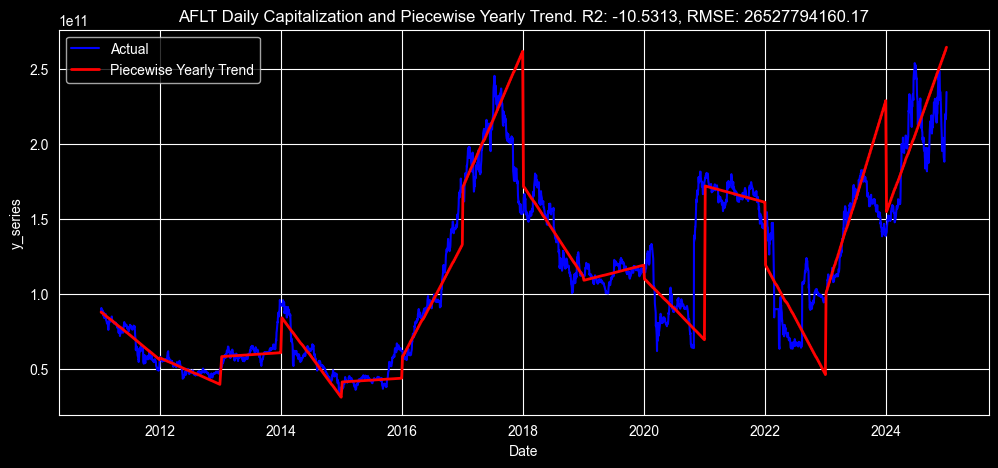

In [295]:
y_series = ticker_metrics['AFLT'][0]['y_series']
trend_series = ticker_metrics['AFLT'][0]['trend_series']
plot_trend(y_series, trend_series, title=f'AFLT Daily Capitalization and Piecewise Yearly Trend. R2: {ticker_metrics["AFLT"][1]["R2"]:.4f}, RMSE: {ticker_metrics["AFLT"][1]["RMSE"]:.2f}')

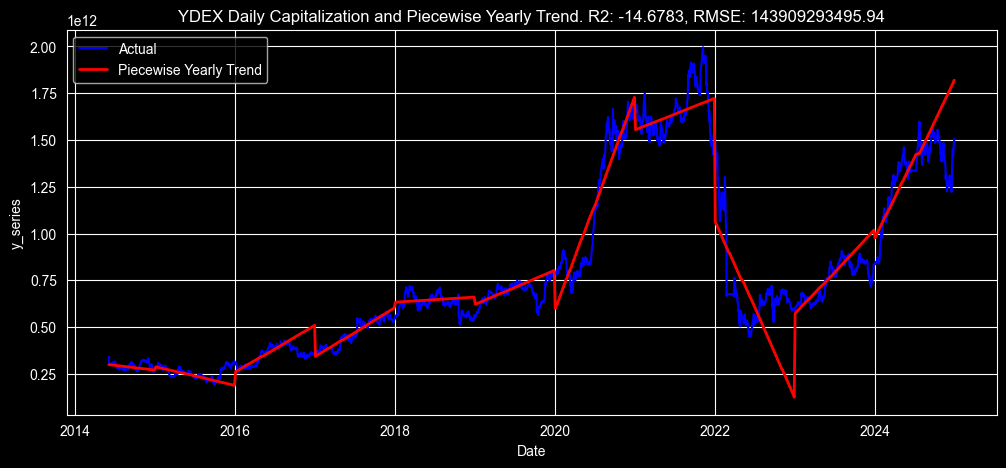

In [296]:
y_series = ticker_metrics['YDEX'][0]['y_series']
trend_series = ticker_metrics['YDEX'][0]['trend_series']
plot_trend(y_series, trend_series, title=f'YDEX Daily Capitalization and Piecewise Yearly Trend. R2: {ticker_metrics["YDEX"][1]["R2"]:.4f}, RMSE: {ticker_metrics["YDEX"][1]["RMSE"]:.2f}')

R2 отрицательный, в качестве бейзлайн модели попробую ARIMA(1, 0, 0) или VAR

## ЧЕРНОВИК sktime TimeSeriesForestRegressor и Feature Selection

https://www.sktime.net/en/stable/api_reference/auto_generated/sktime.regression.interval_based.TimeSeriesForestRegressor.html

	•	Подходит для табличной регрессии временных рядов, когда важно быстрое обучение и интерпретируемость.
	•	Не требует стационарности ряда.

In [300]:
from sktime.regression.interval_based import TimeSeriesForestRegressor
# import zipfile
# with zipfile.ZipFile(cfg.PROJ_ROOT / 'data' / 'processed' / 'dataset_smoothed.csv') as z:
#     with z.open("dataset_smoothed.csv") as f:
#         df = pd.read_csv(
#             f,
#             parse_dates=['tradedate'],
#         )
# df = df.sort_values(['secid', 'tradedate']).set_index(['secid', 'tradedate'])

In [298]:
df = df[~df['log_returns_1'].isna()]

In [319]:
# secid = ['secid']
y_name = 'log_returns_1'
macro = [
    'key_rate', 'inflation', 'str_li_def_new', 'str_li_def', 'claims', 'action_based_repo_fx', 'action_based_secure_loans', 'standing_facilities_repo_fx', 'standing_facilities_secure_loans', 'liabilities', 'deposit_auction_based', 'deposit_standing_facilities', 'cbr_bonds', 'net_cbr_claims', 'corr_acc', 'avgrr', 'gold_price', 'silver_price', 'platinum_price', 'palladium_price', 'usd_price', 'eur_price', 'ruonia_rate', 'ruonia_volume',
]
sector = [c for c in df.columns if c.startswith("sector_")]
share_type = [c for c in df.columns if c.startswith("type_")]
board = [c for c in df.columns if c.startswith("boardid_")]
# log_returns = [c for c in df.columns if c.startswith("log_returns_") and c != y_name]
mults = ['log_volume_1', 'log_capex_revenue_rsbu', 'log_capex_revenue_msfo', 'log_capital_rsbu', 'log_capital_msfo', 'log_current_ratio_rsbu', 'log_current_ratio_msfo', 'log_debt_equity_rsbu', 'log_debt_equity_msfo', 'log_debt_ratio_rsbu', 'log_debt_ratio_msfo', 'log_debtebitda_rsbu', 'log_debtebitda_msfo', 'log_dpr_rsbu', 'log_dpr_msfo', 'log_ebitda_margin_rsbu', 'log_ebitda_margin_msfo', 'log_ev_ebit_rsbu', 'log_ev_ebit_msfo', 'log_evebitda_rsbu', 'log_evebitda_msfo', 'log_evs_rsbu', 'log_evs_msfo', 'log_gross_margin_rsbu', 'log_gross_margin_msfo', 'log_interest_coverage_rsbu', 'log_interest_coverage_msfo', 'log_net_margin_rsbu', 'log_net_margin_msfo', 'log_net_working_capital_rsbu', 'log_net_working_capital_msfo', 'log_netdebt_ebitda_rsbu', 'log_netdebt_ebitda_msfo', 'log_operation_margin_rsbu', 'log_operation_margin_msfo', 'log_pbv_rsbu', 'log_pbv_msfo', 'log_pcf_rsbu', 'log_pcf_msfo', 'log_pe_rsbu', 'log_pe_msfo', 'log_pfcf_rsbu', 'log_pfcf_msfo', 'log_pffo_rsbu', 'log_pffo_msfo', 'log_ps_rsbu', 'log_ps_msfo', 'log_roa_rsbu', 'log_roa_msfo', 'log_roce_rsbu', 'log_roce_msfo', 'log_roe_rsbu', 'log_roe_msfo', 'log_roic_rsbu', 'log_roic_msfo', 'log_ros_rsbu', 'log_ros_msfo',]
funds = [c for c in df.columns if c.startswith("log_line_")]
X = df[
    macro +
    sector +
    share_type +
    board +
    mults +
    funds
    # log_returns
]
X = X.replace([np.inf, -np.inf], np.nan)
y = df[y_name]

Пример Аэрофлот

In [320]:
X.shape

(595036, 282)

In [321]:
aflt = df.xs('AFLT', level='secid')
aflt.shape

(3526, 1058)

In [323]:
from sklearn.ensemble import (RandomForestRegressor,
                              GradientBoostingRegressor,
                              ExtraTreesRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline as sklearn_make_pipeline
from sktime.forecasting.model_selection import temporal_train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sktime.performance_metrics.forecasting import (
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape,
    mean_absolute_scaled_error as mase,
    mean_squared_error as mse
)

from sktime.forecasting.compose import make_reduction
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils import plotting

In [324]:
regressors = {
    'Linear Regression': LinearRegression,
    'Random Forest Regression':
                lambda: RandomForestRegressor(random_state=42),
    'Gradient Boosting Regression':
                lambda: GradientBoostingRegressor(random_state=42),
    'Extra Tree Regression':
                lambda: ExtraTreesRegressor(random_state=42),
    'Support Vector Regression (RBF)':
                lambda: SVR(kernel='rbf'),
    'Support Vector Regression (linear)':
                lambda: SVR(kernel='linear'),
    'K-Nearest Neighbor Regression':
                lambda: KNeighborsRegressor()
}

In [325]:
def train_model(train, test, reg, reg_name, strategy):

    fh = ForecastingHorizon(test.index, is_relative=False)
    sklearn_pipeline = sklearn_make_pipeline(StandardScaler(), reg)

    forecaster = make_reduction(estimator=sklearn_pipeline,
                                window_length=10,
                                strategy=strategy)
    print(f'training {reg_name} ...')
    forecaster.fit(train)
    yhat = forecaster.predict(fh)
    actual = test.copy()

    rmse_test = np.sqrt(mse(actual, yhat))
    mae_test = mae(actual, yhat)
    mape_test = mape(actual, yhat)
    mase_test = mase(actual, yhat, y_train=(train))

    model_metadata = {
        'Model Name': reg_name,
        'Model': forecaster,
        'RMSE': rmse_test,
        'MAPE': mape_test,
        'MASE': mase_test,
        'MAE': mae_test,
        'yhat': yhat,
        'actual': actual}

    return model_metadata

def train_different_models(train, test, regressors, strategy):
    results = []
    for reg_name, reg in regressors.items():
        results.append(train_model(train,
                                   test,
                                   reg(),
                                   reg_name,
                                   strategy))
    return results

In [326]:
aflt = aflt.asfreq('D')

In [332]:
train_cap, test_cap = temporal_train_test_split(aflt['dailycapitalization'].reset_index().set_index('tradedate'), test_size=252)

In [333]:
make_reduction(RandomForestRegressor, strategy='recursive')

RecursiveTabularRegressionForecaster(estimator=<class 'sklearn.ensemble._forest.RandomForestRegressor'>)

In [334]:
make_reduction(RandomForestRegressor, strategy='multioutput')

MultioutputTabularRegressionForecaster(estimator=<class 'sklearn.ensemble._forest.RandomForestRegressor'>)

In [335]:
make_reduction(RandomForestRegressor, strategy='direct')

DirectTabularRegressionForecaster(estimator=<class 'sklearn.ensemble._forest.RandomForestRegressor'>)

In [336]:
"""
Utility functions for Chapter 11: Forecasting Using Supervised Machine Learning
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_absolute_percentage_error as mape
from sktime.performance_metrics.forecasting import mean_absolute_scaled_error as mase
from sktime.forecasting.compose import make_reduction
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_selection import ForecastingGridSearchCV, ExpandingWindowSplitter
from sklearn.pipeline import make_pipeline as sklearn_make_pipeline
from sklearn.multioutput import MultiOutputRegressor

def handle_missing_data(df):
    n = int(df.isna().sum().sum()) # total missing values
    if n > 0:
        print(f'found {n} missing observations...')
        df.ffill(inplace=True)


def multiple_output_features(df, window_in, window_out):
    d = df.values.squeeze()

    x = np.lib.stride_tricks.sliding_window_view(d, window_shape=window_in)[:-window_out]
    y = np.lib.stride_tricks.sliding_window_view(d[window_in:], window_shape=window_out)

    cols_x = [f'x_{i}' for i in range(1, window_in + 1)]
    cols_y = [f'y_{i}' for i in range(1, window_out + 1)]

    df_xs = pd.DataFrame(x, columns=cols_x, index=df.index[window_in:len(df) - window_out + 1])
    df_ys = pd.DataFrame(y, columns=cols_y, index=df.index[window_in:len(df) - window_out + 1])

    return pd.concat([df_xs, df_ys], axis=1)

def split_data(df, test_split=0.10):
    """Split time series data into training and test sets.

    Args:
        df (pd.DataFrame): Time series data to split
        test_split (float, default=0.10): Proportion of data to use for testing

    Returns:
        tuple: (train_df, test_df)
    """
    n = int(len(df) * test_split)
    train, test = df[:-n], df[-n:]
    return train, test

class Standardize:
    def __init__(self):
        self.mu = None
        self.sigma = None

    def _transform(self, df):
        return (df - self.mu) / self.sigma

    def fit_transform(self, train, test):
        # Calculate mean and std on training data only
        self.mu = train.mean()
        self.sigma = train.std()

        # Standardize training and test sets
        train_s = self._transform(train)
        test_s = self._transform(test)
        return train_s, test_s

    def transform(self, df):
        # Apply transformation to any new data
        return self._transform(df)

    def inverse(self, df):
        # Inverse transformation for the whole DataFrame
        return (df * self.sigma) + self.mu

    def inverse_y(self, df):
        # Inverse transformation specifically for the first column (y)
        return (df * self.sigma.iloc[-1]) + self.mu.iloc[-1]

def preprocess(df, split, window=5, generate_features=True):
    """
    Preprocess time series data by handling missing values, generating lagged features (optional),
    splitting into train/test sets, and standardizing.

    Args:
        df (pd.DataFrame): Input dataframe. Can be raw time series or already lagged features.
        split (float): Fraction of data to use for testing.
        window (int, optional): Window size for lagged features. Defaults to 5.
        generate_features (bool, optional): Whether to generate lagged features.
                                            Set to False if df already contains features. Defaults to True.

    Returns:
        tuple: (train_scaled, test_scaled, scaler_object)
    """
    # Handle missing data
    handle_missing_data(df)

    if generate_features:
        # Generate lagged features
        df_os = generate_lagged_features(df, window)
    else:
        df_os = df

    # Split data
    train, test = split_data(df_os, split)

    # Standardize data
    sc = Standardize()
    train_s, test_s = sc.fit_transform(train, test)

    return train_s, test_s, sc



def train_different_models_scaled(train, test, regressors, sc, train_func):
    results = []
    for reg_name, regressor in regressors.items():
        reg = regressor()
        results.append(train_func(train,
                                   test,
                                   reg,
                                   reg_name, sc))
    return results

def evaluate_results(results, by='MASE'):
    cols = ['Model Name', 'RMSE','MAPE', 'MASE']
    df_sorted = results[cols].sort_values(by).reset_index(drop=True)
    return df_sorted

def plot_results(results, data_name):
    cols = ['yhat', 'actual', 'Model Name']
    for row in results[cols].iterrows():
        yhat, actual, name = row[1]
        plt.title(f'{data_name} - {name}')
        plt.plot(actual, 'k--', alpha=0.5)
        plt.plot(yhat, 'k')
        plt.legend(['actual', 'forecast'])
        plt.show()


def train_different_models_mo(train, test, regressors, win_in, win_out, train_func):
    results = []
    for reg_name, regressor in regressors.items():
        result = train_func(
            train=train,
            test=test,
            regressor=regressor,
            reg_name=reg_name,
            win_in=win_in,
            win_out=win_out
        )
        results.append(result)
    return results

def train_different_models_grid_cv(train, test, regressors, train_func):
    results = []
    for reg_name, (reg, param_grid) in regressors.items():
        results.append(train_func(train,
                                   test,
                                   reg(),
                                   reg_name,
                                   param_grid))
    return results


def create_forecaster(reg, window_length=12, strategy='multioutput'):
    sklearn_pipeline = sklearn_make_pipeline(StandardScaler(), reg)
    m_reg = MultiOutputRegressor(sklearn_pipeline)
    return make_reduction(estimator=m_reg, window_length=window_length, strategy=strategy)


def train_model_mo(train, test, regressor, reg_name, win_in, win_out):
    X_train, y_train = train.iloc[:, :win_in], train.iloc[:, win_in:]
    X_test, y_test = test.iloc[:, :win_in], test.iloc[:, win_in:]

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_s = scaler_X.fit_transform(X_train)
    y_train_s = scaler_y.fit_transform(y_train)

    X_test_s = scaler_X.transform(X_test)
    y_test_s = scaler_y.transform(y_test)

    try:
        reg = regressor().fit(X_train_s, y_train_s)
        print(f'Training {reg_name} ...')
    except:
        print(f'{reg_name} does not support multiple outputs')
        try:
            reg = MultiOutputRegressor(regressor()).fit(X_train_s, y_train_s)
            print(f'using sklearn MultipleOutput for {reg_name}')
        except Exception as e:
            print(f'Failed for {reg_name}: {e}')

    yhat = reg.predict(X_test_s)
    yhat = scaler_y.inverse_transform(yhat)
    actual = y_test.values

    # Compute evaluation metrics for multi-output, with multioutput='uniform_average'
    rmse_test = np.sqrt(mse(actual, yhat, multioutput='uniform_average'))
    mae_test = mae(actual, yhat, multioutput='uniform_average')
    mape_test = np.mean(np.abs((actual - yhat) / actual)) * 100
    mase_test = mase(actual, yhat, y_train=y_train)

    residuals = actual - yhat

    model_metadata = {
        'Model Name': reg_name,
        'Model': reg,
        'RMSE': rmse_test,
        'MAPE': mape_test,
        'MASE': mase_test,
        'MAE': mae_test,
        'test': X_test,
        'yhat': pd.DataFrame(yhat, index=y_test.index, columns=y_test.columns),
        'resid': pd.DataFrame(residuals, index=y_test.index, columns=y_test.columns),
        'actual': y_test
    }

    return model_metadata



from sklearn.multioutput import MultiOutputRegressor

def train_model_sktime_mo(train, test, reg, reg_name, strategy):


    fh = ForecastingHorizon(test.index, is_relative=False)
    sklearn_pipeline = sklearn_make_pipeline(StandardScaler(), reg)

    try:
        forecaster = make_reduction(estimator=sklearn_pipeline,
                                window_length=10,
                                strategy=strategy)
        forecaster.fit(train, fh=fh)
        print(f'training {reg_name} ...')
    except:
        try:
            mo_reg = MultiOutputRegressor(sklearn_pipeline)
            forecaster = make_reduction(estimator=mo_reg,
                                window_length=10,
                                strategy=strategy)
            forecaster.fit(train, fh=fh)
            print(f'using MultiOutputRegressor for {reg_name} ...')
        except Exception as e:
            print(f'Failed for {reg_name}: {e}')

    yhat = forecaster.predict(fh)
    actual = test.copy()

    rmse_test = np.sqrt(mse(actual, yhat))
    mae_test = mae(actual, yhat)
    mape_test = mape(actual, yhat)
    mase_test = mase(actual, yhat, y_train=(train))

    model_metadata = {
        'Model Name': reg_name,
        'Model': forecaster,
        'RMSE': rmse_test,
        'MAPE': mape_test,
        'MASE': mase_test,
        'MAE': mae_test,
        'yhat': yhat,
        'actual': actual}

    return model_metadata


def train_different_models_sktime_mo(train, test, regressors, strategy):
    results = []
    for reg_name, regressor in regressors.items():
        reg = regressor()
        results.append(train_model_sktime_mo(train,
                                   test,
                                   reg,
                                   reg_name,
                                   strategy))
    return results


def train_model_sktime_cv(train, test, reg, reg_name, param_grid):

    # Full forecasting horizon for prediction
    fh = ForecastingHorizon(test.index, is_relative=False)

    # Multi-step horizon for CV
    fh_cv = np.arange(1, min(30, len(test) + 1))

    sklearn_pipeline = sklearn_make_pipeline(StandardScaler(), reg)

    # Define a 3-fold expanding window CV cross-validation strategy
    initial_window = max(50, len(train) // 3)
    remaining_length = len(train) - initial_window
    step_length = max(1, (remaining_length - len(test)) // 2)

    cv = ExpandingWindowSplitter(initial_window=initial_window,
                                 step_length=step_length,
                                 fh=fh_cv)

    try:
        # Wrap the regressor in a MultiOutputRegressor
        m_reg = MultiOutputRegressor(sklearn_pipeline)
        forecaster = make_reduction(estimator=m_reg,
                                window_length=10, # 10 lags, adjustable
                                strategy="multioutput")

        # Perform grid search with cross-validation
        gscv = ForecastingGridSearchCV(
                        forecaster=forecaster,
                        param_grid=param_grid,
                        cv=cv,
                        verbose=1)

        gscv.fit(train, fh=fh)
        print(f'Grid Search CV using MultiOutputRegressor for {reg_name} ...')
    except Exception as e:
        print(f'Failed for {reg_name}: {e}')
        return

    # Generate predictions and evaluate
    yhat = gscv.predict(fh)
    actual = test.copy()

    # Evaluate model performance using various metrics
    rmse_test = np.sqrt(mse(actual, yhat))
    mae_test = mae(actual, yhat)
    mape_test = mape(actual, yhat)
    mase_test = mase(actual, yhat, y_train=(train))

    model_metadata = {
        'Model Name': reg_name,
        'Model': gscv,
        'RMSE': rmse_test,
        'MAPE': mape_test,
        'MASE': mase_test,
        'MAE': mae_test,
        'yhat': yhat,
        'actual': actual}

    return model_metadata

def train_different_models_sktime_cv(train, test, regressors):
    results = []
    for reg_name, regressor in regressors.items():
        reg = regressor[0]()
        param_grid = regressor[1]
        results.append(train_model_sktime_cv(train,
                                   test,
                                   reg,
                                   reg_name,
                                   param_grid))
    return results

In [ ]:
results = []
for reg_name, regressor in regressors.items():
        reg = regressor()
        results.append(train_model_sktime_mo(train,
                                   test,
                                   reg,
                                   reg_name,
                                   strategy))

In [337]:
%%time

results_mo = train_different_models_sktime_mo(
    train_cap,
    test_cap,
    regressors,
    "multioutput",
    # train_func=train_model_sktime_mo,
)

Failed for Linear Regression: Input y contains NaN.
CPU times: user 30.3 ms, sys: 11.5 ms, total: 41.9 ms
Wall time: 40.8 ms


NotFittedError: This instance of MultioutputTabularRegressionForecaster has not been fitted yet. Please call `fit` first.

In [ ]:
results_mo_df = pd.DataFrame(results_mo)
results_mo_sorted = evaluate_results(results_mo_df)
print(results_mo_sorted.loc[:, ['Model Name', 'MASE']].head(3))

In [ ]:
for i, row in results_mo_df[['yhat', 'actual', 'Model Name', 'MAPE']].iterrows():
        yhat, actual, name, mape = row
        plt.title(f'AFLT Daily Capitalization - {name}. MAPE: {mape:.2f}%')
        plt.plot(actual, 'k--', alpha=0.5, color='red')
        plt.plot(yhat, 'k', color='white', alpha=0.5, linestyle='dashed')
        plt.legend(['actual', 'forecast'])
        plt.show()

In [ ]:
# import pandas as pd
# from sktime.regression.interval_based import TimeSeriesForestRegressor
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_squared_error
# import numpy as np
#
#
# # X_sktime = X.copy()
# # for col in X.columns:
# #     X_sktime[col] = X_sktime[col].apply(lambda v: [v])  # превращаем каждый элемент в список
#
# tsf = TimeSeriesForestRegressor(n_estimators=100, random_state=42)
#
# tscv = TimeSeriesSplit(n_splits=5)
# mse_scores = []
#
# for train_index, test_index in tscv.split(X_sktime):
#     X_train, X_test = X_sktime.iloc[train_index], X_sktime.iloc[test_index]
#     y_train, y_test = y.iloc[train_index], y.iloc[test_index]
#
#     tsf.fit(X_train, y_train)
#     y_pred = tsf.predict(X_test)
#     mse = mean_squared_error(y_test, y_pred)
#     mse_scores.append(mse)
#
# print("MSE по каждому разбиению:", mse_scores)
# print("Средний MSE:", np.mean(mse_scores))